In [1]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')
%cd 'drive/MyDrive/limits-of-icl/src'

!pip install wand munch

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names, plot_param_sweep

%matplotlib inline
#%load_ext autoreload
#%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/limits-of-icl/src


In [2]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

../models/linear_regression/dabb65f6-7e9b-4b32-b796-2a5af901efd2/config.yaml
../models/linear_regression/nanogpt_softmax_test/config.yaml
../models/linear_regression/pretrained/config.yaml
3 3


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
2,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
0,dabb65f6-7e9b-4b32-b796-2a5af901efd2,linear_regression,Transformer,,-1,-1,5,12,8,linear_regression_toy
1,nanogpt_softmax_test,linear_regression,nanogpt_softmax_test,,-1,-1,20,12,8,nanogpt_softmax_test


In [3]:
task = "linear_regression"
#task = "sparse_linear_regression"
#task = "decision_tree"
#task = "relu_2nn_regression"

run_id = "nanogpt_softmax_test"  # if you train more models, replace with the run_id from the table above

run_path = os.path.join(run_dir, task, run_id)
recompute_metrics = True

if recompute_metrics:
    results = get_run_metrics(run_path)  # these are normally precomputed at the end of training

import json
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)


../models/linear_regression/nanogpt_softmax_test/config.yaml
number of parameters: 9.48M
odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2

  0%|          | 0/33 [00:00<?, ?it/s]

Evaluating standard 1
Evaluating model: nanogpt_embd=256_layer=12_head=8_attn=softmax_causal False
20


  3%|▎         | 1/33 [00:00<00:29,  1.07it/s]

Evaluating scaled_query_scale=0.5 2
Evaluating model: nanogpt_embd=256_layer=12_head=8_attn=softmax_causal False
20


...

Evaluating sparseLR_k=10 32
Evaluating model: nanogpt_embd=256_layer=12_head=8_attn=softmax_causal False
20


 97%|█████████▋| 32/33 [00:28<00:00,  1.15it/s]

Evaluating uniform_w_dist 33
Evaluating model: nanogpt_embd=256_layer=12_head=8_attn=softmax_causal False
20


100%|██████████| 33/33 [00:28<00:00,  1.14it/s]

{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.028620433062314987], 'std': [0.0529562346637249], 'bootstrap_low': [0.026328066363930702], 'bootstrap_high': [0.03126157447695732]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.010877428576350212], 'std': [0.017159506678581238], 'bootstrap_low': [0.010088767856359482], 'bootstrap_high': [0.01168989110738039]}}, 'scaled_query_scale=2.0': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.7181106805801392], 'std': [6.653783321380615], 'bootstrap_low': [0.4542972147464752], 'bootstrap_high': [1.067791223526001]}}, 'scaled_query_scale=5.0': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [151.8308563232422], 'std': [336.0713195800781], 'bootstrap_low': [137.04534912109375], 'bootstrap_high': [168.65394592285156]}}, 'opposite_quadrants_num_flipped=1': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.1562

In [ ]:
state = torch.load("../models/linear_regression/nanogpt_softmax_test/state.pt", map_location=torch.device('cpu'))

In [ ]:
state['model_state_dict'].keys()

odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2.weight', '_backbone.transformer.h.1.ln_2.bias', '_backbone.transformer.h.1.mlp.c_fc.weig

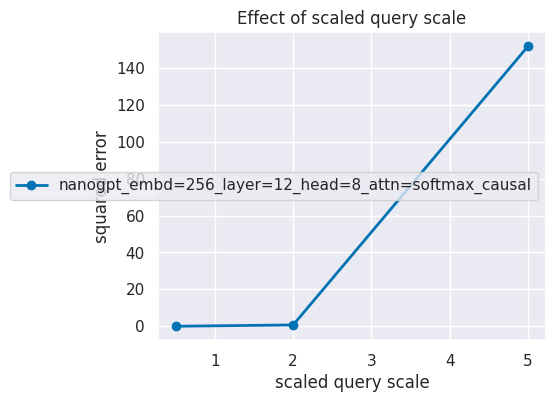

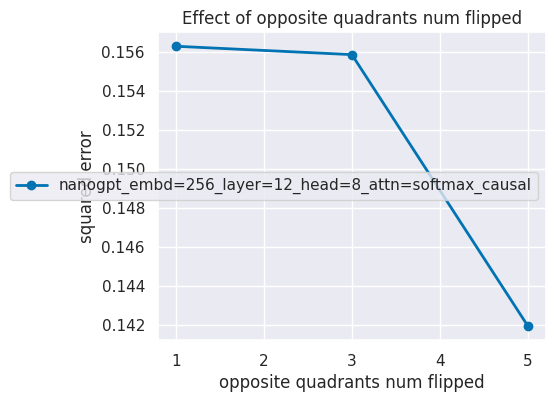

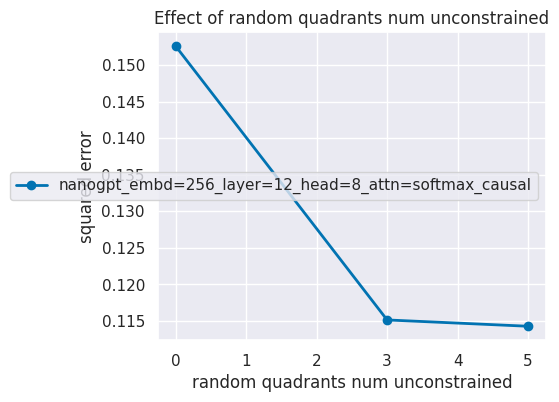

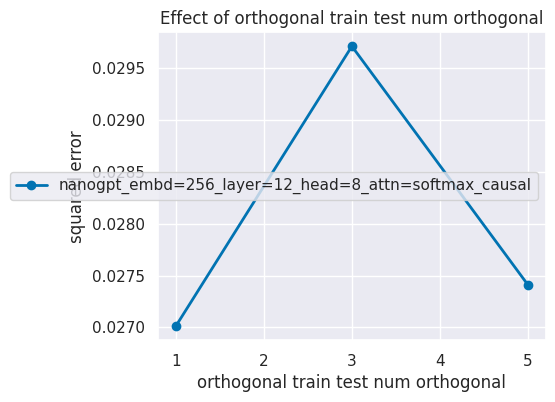

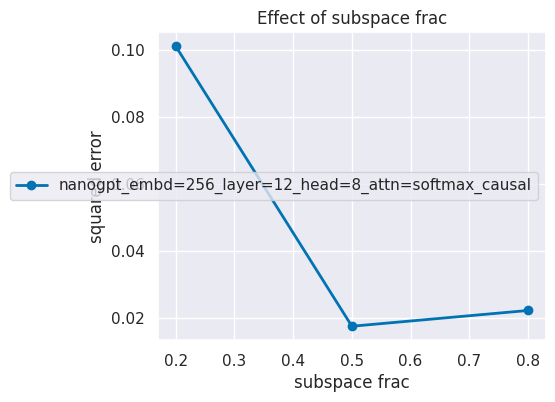

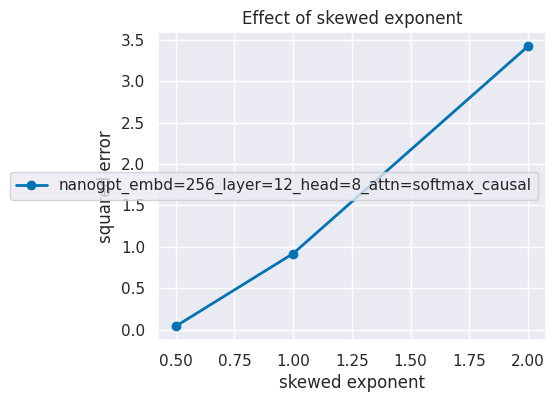

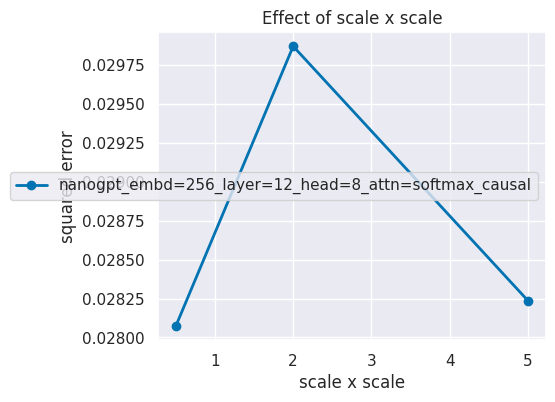

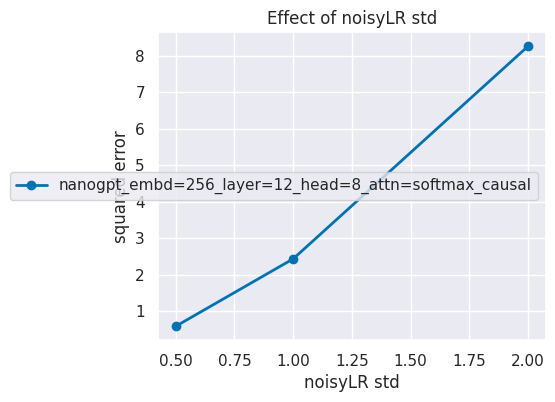

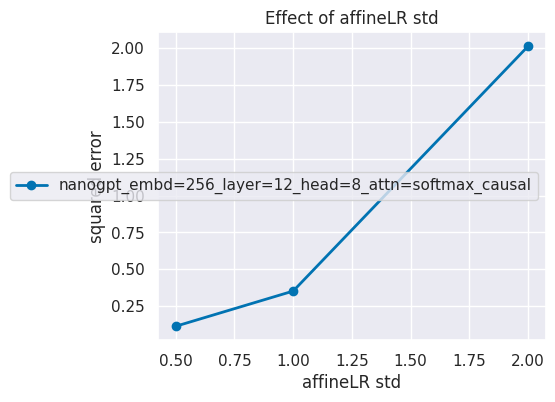

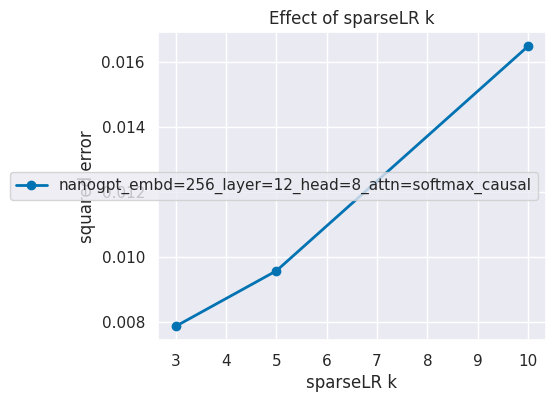

In [4]:
import json

with open("results.json", "r") as f:
    results = json.load(f)

figs = plot_param_sweep(results)
for fig in figs:
    plt.show()